# Experiment No: 2 Vanishing Gradient Problem

### Reason for experimentation

We know that Hyperbolic Tangent (Tanh) and Sigmoid both have their maximum gradient value of **1** and **0.25** respectively at input value of 0 and fall towards 0 as we move away from 0 which leads to poor to no information propagation towards the initial layers of a neural network model which is popularly known as **Vanishing Gradients**. Rectified Linear Unit (ReLU) non linear function was proposed to solve for this vanishing gradient problem as it's gradient's maximum value is 1 for any value larger than 0 and 0 in other cases.

To see if ReLU really solves the problem of vanishing gradients this experiment is being done

To know more about sigmoid, sigmoid and ReLU functions in details you can look at the notebook `/notebooks/activation_functions.ipynb`

### Experiment Design

The following procedure will be carried out in the experiment:
1. The experiment will run on only one dataset (MNIST dataset)
2. Each experiment will be repeated 3 times and the average result will be reported to reduce the effect of randomness.
3. Each experiment will use 2 ANNs one with Sigmoid as it's non linear activation function and the other using ReLU.
4. **Mean Absolute** value will be used to measure gradients propagated per layer in the model

The following parameters will remain constant:
1. Total number of layers will remain fixed at 12 (1 input + 10 hidden + 1 output).
2. Total number of hidden weights will be 128 in each hidden layer.
3. The batch size will be 256.
4. The learning rate will be 0.01.
5. Sigmoid activation function is chosen to over tanh as the maximum value sigmoid's gradient is 0.25 compared to tanh's 1 which allows that ideal vanishing curves to be seen.

### Expected result
The gradients propagated back will reduce in magnitude as we move closer to the upstream layers in case of model using sigmoid non linear activation function where as in case of relu gradients propagated will fall in the same order of magnitude

## Import libraries to be used throughout the experiment

In [17]:
import json
import math
import torch
import pandas as pd
from typing import Self
import matplotlib.pyplot as plt

from pathlib import Path
from torch.optim import SGD

from torchvision.transforms import v2
from torchvision.datasets import MNIST
from torch.utils.data import DataLoader

# RANDOM STATE FOR REPRODUCIBILITY
RANDOM_STATE = 42

%matplotlib inline

## Result and dataset storage path

In [18]:
current_dir = Path.cwd()

# Path to the folder where MNIST dataset will be downloaded
dataset_root_folder = current_dir.parent / 'datasets' / 'mnist_dataset'

# Path to the file where the results of this experimentation will be stored
results_path = current_dir.parent / 'results' / '02_vanishing_gradient_analysis.json'

# Store the absolute path required for the dataset and result file
dataset_root_abs_path = dataset_root_folder.absolute()
result_abs_path = results_path.absolute()

## Classes to be used throughout the experiment

In [19]:
class SigmoidANNModel(torch.nn.Module):
    """
    Class representing an ANN to be used to train on MNIST using sigmoid as it's activation function
    """

    def __init__(self) -> Self:
        """
        Method to initialize an instance of :class: SigmoidANNModel

        :returns: Instance of :class: SigmoidANNModel
        """

        super().__init__()
        
        self.sequential_layers = torch.nn.Sequential(
            torch.nn.Flatten(),
            torch.nn.Linear(in_features=28 * 28, out_features=128, bias=False),
            torch.nn.Sigmoid(),
            torch.nn.Linear(in_features=128, out_features=128, bias=False),
            torch.nn.Sigmoid(),
            torch.nn.Linear(in_features=128, out_features=128, bias=False),
            torch.nn.Sigmoid(),
            torch.nn.Linear(in_features=128, out_features=128, bias=False),
            torch.nn.Sigmoid(),
            torch.nn.Linear(in_features=128, out_features=128, bias=False),
            torch.nn.Sigmoid(),
            torch.nn.Linear(in_features=128, out_features=128, bias=False),
            torch.nn.Sigmoid(),
            torch.nn.Linear(in_features=128, out_features=128, bias=False),
            torch.nn.Sigmoid(),
            torch.nn.Linear(in_features=128, out_features=128, bias=False),
            torch.nn.Sigmoid(),
            torch.nn.Linear(in_features=128, out_features=128, bias=False),
            torch.nn.Sigmoid(),
            torch.nn.Linear(in_features=128, out_features=128, bias=False),
            torch.nn.Sigmoid(),
            torch.nn.Linear(in_features=128, out_features=128, bias=False),
            torch.nn.Sigmoid(),
            torch.nn.Linear(in_features=128, out_features=10, bias=False)
        )

    def forward(self, X: torch.Tensor) -> torch.Tensor:
        """
        Method to propagate the input tensor through the sequential layers

        :param X: Input tensor

        :returns: Result of forward propagation on the input tensor 'X'
        """

        return self.sequential_layers.forward(X)
    

class ReLUANNModel(torch.nn.Module):
    """
    Class representing an ANN to be used to train on MNIST using ReLU as it's activation function
    """

    def __init__(self) -> Self:
        """
        Method to initialize an instance of :class: ReLUANNModel

        :returns: Instance of :class: ReLUANNModel
        """

        super().__init__()
        
        self.sequential_layers = torch.nn.Sequential(
            torch.nn.Flatten(),
            torch.nn.Linear(in_features=28 * 28, out_features=128, bias=False),
            torch.nn.ReLU(),
            torch.nn.Linear(in_features=128, out_features=128, bias=False),
            torch.nn.ReLU(),
            torch.nn.Linear(in_features=128, out_features=128, bias=False),
            torch.nn.ReLU(),
            torch.nn.Linear(in_features=128, out_features=128, bias=False),
            torch.nn.ReLU(),
            torch.nn.Linear(in_features=128, out_features=128, bias=False),
            torch.nn.ReLU(),
            torch.nn.Linear(in_features=128, out_features=128, bias=False),
            torch.nn.ReLU(),
            torch.nn.Linear(in_features=128, out_features=128, bias=False),
            torch.nn.ReLU(),
            torch.nn.Linear(in_features=128, out_features=128, bias=False),
            torch.nn.ReLU(),
            torch.nn.Linear(in_features=128, out_features=128, bias=False),
            torch.nn.ReLU(),
            torch.nn.Linear(in_features=128, out_features=128, bias=False),
            torch.nn.ReLU(),
            torch.nn.Linear(in_features=128, out_features=128, bias=False),
            torch.nn.ReLU(),
            torch.nn.Linear(in_features=128, out_features=10, bias=False)
        )

    def forward(self, X: torch.Tensor) -> torch.Tensor:
        """
        Method to propagate the input tensor through the sequential layers

        :param X: Input tensor

        :returns: Result of forward propagation on the input tensor 'X'
        """

        return self.sequential_layers.forward(X)

## Load MNIST dataset

In [20]:
torch.manual_seed(RANDOM_STATE)
torch.cuda.manual_seed(RANDOM_STATE)

# Transforms required to convert the original 28x28 single channeled MNIST images into torch tensor of type float 32
feature_transforms = v2.Compose([
    v2.ToImage(),
    v2.ToDtype(dtype=torch.float32),
    v2.Normalize(mean=(0.1307,), std=(0.3081,)) # These values are what are to be used to perform standardization of the MNIST images
])

# Convert class labels to one hot encoded labels
target_transforms = v2.Lambda(lambda x: torch.nn.functional.one_hot(torch.tensor(x), num_classes=10).float())

# Load MNIST dataset
mnist_dataset = MNIST(root=dataset_root_abs_path,
                      train=True,
                      download=True,
                      transform=feature_transforms,
                      target_transform=target_transforms)

# Load the dataset onto a dataloader to create batches of size 256
mnist_dataloader = DataLoader(dataset=mnist_dataset,
                              batch_size=256,
                              shuffle=True)

## Run the experiment

In [21]:
torch.manual_seed(RANDOM_STATE)
torch.cuda.manual_seed(RANDOM_STATE)

# Set learning rate, number of experiments to run to reduce the effect of randomness and device to be used to run the experiment on 
LEARNING_RATE = 1e-2
NUMBER_OF_EXPERIMENTS = 3
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

# Result storage dictionary
sigmoid_experiment_results, relu_experiment_results = {}, {}

# Initialize models
sigmoid_model = SigmoidANNModel()
relu_model = ReLUANNModel()

# Load loss function and optimizers
loss_function = torch.nn.CrossEntropyLoss()
sigmoid_optimizer = SGD(params=sigmoid_model.parameters(), lr=LEARNING_RATE)
relu_optimizer = SGD(params=relu_model.parameters(), lr=LEARNING_RATE)

# Move models to device
sigmoid_model = sigmoid_model.to(DEVICE)
relu_model = relu_model.to(DEVICE)

# Switch model to training mode
sigmoid_model.train()
relu_model.train()

# Loop through the number of experiments
for experiment_number in range(NUMBER_OF_EXPERIMENTS):

    relu_epoch_gradients = {}
    sigmoid_epoch_gradients = {}
    sigmoid_batch_gradients = {i: [] for i in range(1, 11)}
    relu_batch_gradients = {i: [] for i in range(1, 11)}

    # Only loop through the dataset only once
    for X, y in mnist_dataloader:
        X = X.to(DEVICE)
        y = y.to(DEVICE)
        sigmoid_y_hat = sigmoid_model.forward(X)
        relu_y_hat = relu_model.forward(X)
        sigmoid_optimizer.zero_grad()
        relu_optimizer.zero_grad()
        sigmoid_loss = loss_function.forward(sigmoid_y_hat, y)
        relu_loss = loss_function.forward(relu_y_hat, y)
        sigmoid_loss.backward()
        relu_loss.backward()

        for index, param in enumerate(sigmoid_model.parameters()):
            if index in [0, 11]:
                continue
            sigmoid_batch_gradients[index].append(param.grad.flatten().unsqueeze(dim=0).cpu())
        for index, param in enumerate(relu_model.parameters()):
            if index in [0, 11]:
                continue
            relu_batch_gradients[index].append(param.grad.flatten().unsqueeze(dim=0).cpu())

        sigmoid_optimizer.step()
        relu_optimizer.step()

    # Calculate the mean absolute value of the gradients per layer per epoch
    for layer in sigmoid_batch_gradients:
        gradient_tensor = torch.vstack(sigmoid_batch_gradients[layer])
        # Take absolute of all gradients 
        gradient_tensor = torch.abs(gradient_tensor)
        # Take mean along the first dimension
        gradient_tensor = gradient_tensor.mean(dim=0)
        gradient_tensor = gradient_tensor.mean(dim=0)
        sigmoid_epoch_gradients[layer] = gradient_tensor.item()

    for layer in relu_batch_gradients:
        gradient_tensor = torch.vstack(relu_batch_gradients[layer])
        # Take absolute of all gradients 
        gradient_tensor = torch.abs(gradient_tensor)
        # Take mean along the first dimension
        gradient_tensor = gradient_tensor.mean(dim=0)
        # Take mean along the second dimension
        gradient_tensor = gradient_tensor.mean(dim=0)
        relu_epoch_gradients[layer] = gradient_tensor.item()
    
    # store it against the experiment number
    sigmoid_experiment_results[experiment_number + 1] = sigmoid_epoch_gradients
    relu_experiment_results[experiment_number + 1] = relu_epoch_gradients

# Store the values as one single result file
final_result_dict = {'sigmoid': sigmoid_experiment_results,
                     'relu': relu_experiment_results}

with Path.open(result_abs_path, mode='w') as file:
    json.dump(final_result_dict, file)


## Plot Graph

Graph that visualizes the order of magnitude of gradients across the 10 hidden layers. For each activation function layer gradients are normalized by the minimum gradient value found across all hidden layers. Taking the base-10 logarithm to compare gradient propagation taking place in Sigmoid and ReLU network on a standardized scale.

We can see that as we go towards the upstream hidden layers (layer 1, 2, ...) the gradient's magnitude drops by an order of magnitude for sigmoid network where as in case of ReLU network it remains within the same order of magnitude which clearly demonstrates **vanishing gradients** taking place in case of sigmoid network

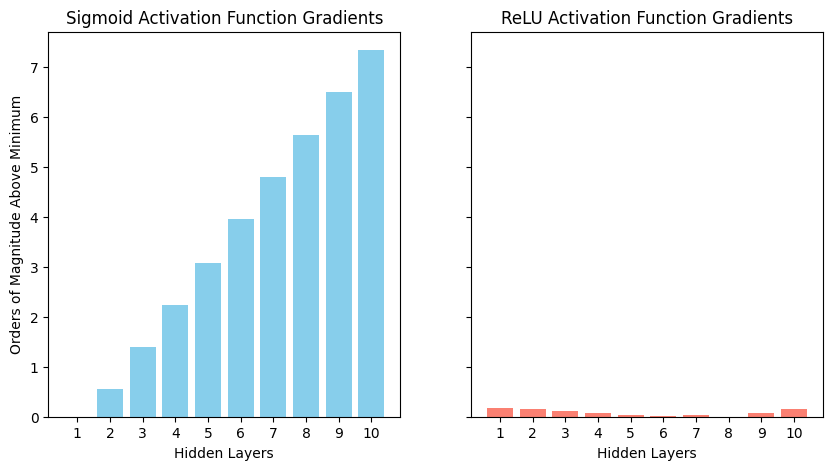

In [22]:
# Open stored results
with Path.open(result_abs_path, mode='r') as file:
    experiment_results = json.load(file)

sigmoid_results, relu_results = experiment_results['sigmoid'], experiment_results['relu']

average_sigmoid_results, average_relu_results = {str(i): [] for i in range(1, 11)}, {str(i): [] for i in range(1, 11)}

# Combine results spread across experiments as one by taking their average
for experiment in sigmoid_results:
    for layer in sigmoid_results[experiment]:
        average_sigmoid_results[layer].append(sigmoid_results[experiment][layer])

for experiment in relu_results:
    for layer in relu_results[experiment]:
        average_relu_results[layer].append(relu_results[experiment][layer])

for layer in average_sigmoid_results:
    average_sigmoid_results[layer] = sum(average_sigmoid_results[layer]) / len(average_sigmoid_results[layer])

for layer in average_relu_results:
    average_relu_results[layer] = sum(average_relu_results[layer]) / len(average_relu_results[layer])

# Dividing the results using the minimum and then taking the log
sigmoid_minimum = min([value for value in average_sigmoid_results.values()])
relu_minimum = min([value for value in average_relu_results.values()])

for layer in average_sigmoid_results:
    average_sigmoid_results[layer] = math.log10(average_sigmoid_results[layer] / sigmoid_minimum)

for layer in average_relu_results:
    average_relu_results[layer] = math.log10(average_relu_results[layer] / relu_minimum)

# Create a pandas dataframe of gradients
df = pd.DataFrame({'Layers': list(range(1, 11)),
                   'Sigmoid': list(average_sigmoid_results.values()), 
                   'ReLU': list(average_relu_results.values())})

fig, axes = plt.subplots(nrows=1, ncols=2, sharey=True, figsize=(10, 5))

# Plot order of gradient's magnitude over the minimum value
axes[0].bar(x=df['Layers'], height=df['Sigmoid'], color='skyblue')
axes[1].bar(x=df['Layers'], height=df['ReLU'], color='salmon')

axes[0].set_xticks(list(range(1, 11)))
axes[1].set_xticks(list(range(1, 11)))

axes[0].set_xlabel("Hidden Layers")
axes[1].set_xlabel("Hidden Layers")

axes[0].set_title('Sigmoid Activation Function Gradients')
axes[1].set_title('ReLU Activation Function Gradients')

axes[0].set_ylabel("Orders of Magnitude Above Minimum")

plt.show()
